# Notebook 06: Slippage

## Objective

Investigate the impact of slippage on backtest performance.

Slippage occurs when trades execute at prices different from those assumed in a backtest.

Even when commissions and fees are known, investors may not obtain their expected execution price due to market conditions, liquidity constraints, and order-book dynamics.

This notebook evaluates how slippage further reduces the profitability of a trading strategy beyond explicit transaction costs.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

sys.path.append("..")
from src.data_loader import load_data
from src.metrics import total_return,sharpe_ratio,max_drawdown

In [2]:
df=load_data("SPY")
print(df.head())

d:\Portfolio\Quant Projects\Backtesting-Bias-Analysis-main\Backtesting-Bias-Analysis-main\notebooks\..\src\data_loader.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker,start="2020-01-01")
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker             SPY         SPY         SPY         SPY       SPY
Date                                                                
2020-01-02  296.888153  296.906448  294.749706  295.672721  59151200
2020-01-03  294.640015  295.764082  293.442850  293.497680  77709700
2020-01-06  295.764130  295.846374  292.766617  292.885424  55653900
2020-01-07  294.932495  295.672726  294.484681  295.197497  40496400
2020-01-08  296.504395  297.719826  294.877711  295.124445  68296000


In [3]:
df = load_data("SPY")

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df.head()

d:\Portfolio\Quant Projects\Backtesting-Bias-Analysis-main\Backtesting-Bias-Analysis-main\notebooks\..\src\data_loader.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker,start="2020-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,296.888062,296.906357,294.749615,295.672630,59151200
2020-01-03,294.640045,295.764112,293.442881,293.497711,77709700
2020-01-06,295.764130,295.846374,292.766617,292.885424,55653900
2020-01-07,294.932495,295.672726,294.484681,295.197497,40496400
2020-01-08,296.504333,297.719765,294.877650,295.124385,68296000


In [4]:
df["SMA_50"] = df["Close"].rolling(50).mean()
df["SMA_200"] = df["Close"].rolling(200).mean()

df["Signal"] = 0
df.loc[df["SMA_50"] > df["SMA_200"], "Signal"] = 1

df[["Close", "SMA_50", "SMA_200", "Signal"]].tail()

Price,Close,SMA_50,SMA_200,Signal
Date,,,,
2026-06-08,739.219971,715.394399,682.097072,1
2026-06-09,737.049988,717.453599,682.631300,1
2026-06-10,725.429993,719.322799,683.059038,1
2026-06-11,737.760010,721.071199,683.562507,1
2026-06-12,741.750000,722.801399,684.072589,1


In [5]:
df["Returns"] = df["Close"].pct_change()

df["Strategy_Returns"] = (
    df["Signal"].shift(1) * df["Returns"]
)

df[["Returns", "Strategy_Returns"]].head()

Price,Returns,Strategy_Returns
Date,,
2020-01-02,NaN,NaN
2020-01-03,-0.007572,-0.0
2020-01-06,0.003815,0.0
2020-01-07,-0.002812,-0.0
2020-01-08,0.005329,0.0


In [6]:
df["Trades"] = df["Signal"].diff().abs()

transaction_cost = 0.001
slippage = 0.0005

In [12]:
df["Strategy_Returns_TC"] = (
    df["Strategy_Returns"]
    - df["Trades"] * transaction_cost
)
df["Strategy_Returns_Slip"] = (
    df["Strategy_Returns"]
    - df["Trades"] * transaction_cost
    - df["Trades"] * slippage
)

In [19]:
df["Equity_TC"] = (
    1 + df["Strategy_Returns_TC"].fillna(0)
).cumprod()

In [20]:
df["Equity_Slip"] = (
    1 + df["Strategy_Returns_Slip"].fillna(0)
).cumprod()

In [21]:
df["Equity"] = (1 + df["Strategy_Returns"].fillna(0)).cumprod()
df["Market"] = (1 + df["Returns"].fillna(0)).cumprod()

Text(0.5, 1.0, 'Impact of Slippage')

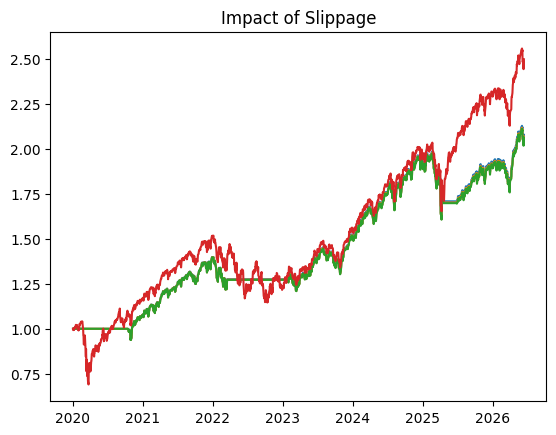

In [22]:
plt.plot(df.index,
         df["Equity"],
         label="Baseline")

plt.plot(df.index,
         df["Equity_TC"],
         label="Transaction Costs")

plt.plot(df.index,
         df["Equity_Slip"],
         label="Costs + Slippage")

plt.plot(df.index,
         df["Market"],
         label="Buy & Hold")
plt.title("Impact of Slippage")

In [16]:
returns_slip = df["Strategy_Returns_Slip"].dropna()

print("\nWITH SLIPPAGE")

print("Total Return:",
      round(total_return(df["Equity_Slip"])*100,2),
      "%")

print("Sharpe Ratio:",
      round(sharpe_ratio(returns_slip),2))

print("Max Drawdown:",
      round(max_drawdown(df["Equity_Slip"])*100,2),
      "%")


WITH SLIPPAGE
Total Return: 106.31 %
Sharpe Ratio: 0.95
Max Drawdown: -18.76 %


## Interpretation

Transaction costs represent known expenses associated with trading.

Slippage introduces an additional layer of uncertainty by reflecting the difference between expected and realized execution prices.

Although the effect was modest for this low-frequency SMA strategy, slippage can significantly impair the performance of more active trading systems.

Ignoring slippage may therefore produce overly optimistic estimates of strategy profitability.
# Conclusion

Real-world implementation involves both explicit and implicit trading frictions.

A strategy that appears attractive in an idealized backtest must also survive commissions, fees, and execution inefficiencies.

Robust quantitative research therefore evaluates not only statistical performance but also practical implementability under realistic market conditions.